In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
df = pd.read_excel(
    "../../data/road_fine.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "lifecycle:transition": "string",
        "org:resource": "string",
        "dismissal": "string",
        "vehicleClass": "string",
        "notificationType": "string",
        "lastSent": "string",
        "amount": "float32",
        "totalPaymentAmount": "float32",
        "article": "float32",
        "points": "float32",
        "expense": "float32",
        "paymentAmount": "float32",
        "time_delta": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,amount,article,concept:name,dismissal,expense,lastSent,lifecycle:transition,notificationType,org:resource,paymentAmount,points,time_delta,totalPaymentAmount,vehicleClass
0,A1,2006-07-24,35.0,157.0,Create Fine,NIL,0.0,NA,complete,NA,561,0.0,0.0,0.0,0.0,A
1,A1,2006-12-05,0.0,0.0,Send Fine,NA,11.0,NA,complete,NA,NA,0.0,0.0,11577600.0,0.0,NA
2,A100,2006-08-02,35.0,157.0,Create Fine,NIL,0.0,NA,complete,NA,561,0.0,0.0,0.0,0.0,A
3,A100,2006-12-12,0.0,0.0,Send Fine,NA,11.0,NA,complete,NA,NA,0.0,0.0,11404800.0,0.0,NA
4,A100,2007-01-15,0.0,0.0,Insert Fine Notification,NA,0.0,P,complete,P,NA,0.0,0.0,2937600.0,0.0,NA
5,A100,2007-03-16,71.5,0.0,Add penalty,NA,0.0,NA,complete,NA,NA,0.0,0.0,5184000.0,0.0,NA
6,A100,2009-03-30,0.0,0.0,Send for Credit Collection,NA,0.0,NA,complete,NA,NA,0.0,0.0,64368000.0,0.0,NA
7,A10000,2007-03-09,36.0,157.0,Create Fine,NIL,0.0,NA,complete,NA,561,0.0,0.0,0.0,0.0,A
8,A10000,2007-07-17,0.0,0.0,Send Fine,NA,13.0,NA,complete,NA,NA,0.0,0.0,11232000.0,0.0,NA
9,A10000,2007-08-02,0.0,0.0,Insert Fine Notification,NA,0.0,P,complete,P,NA,0.0,0.0,1382400.0,0.0,NA


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['amount', 'article', 'concept:name', 'dismissal', 'expense', 'lastSent', 'lifecycle:transition', 'notificationType', 'org:resource', 'paymentAmount', 'points', 'time_delta', 'totalPaymentAmount', 'vehicleClass']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
time_delta                     continuous     event    yes    [0.00, 8726400.00]                       2160000.0000 quantile_derived    
amount                         continuous     event    yes    [24.00, 80.00]                           6.7000     quantile_derived    
totalPaymentAmount             continuous     event

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

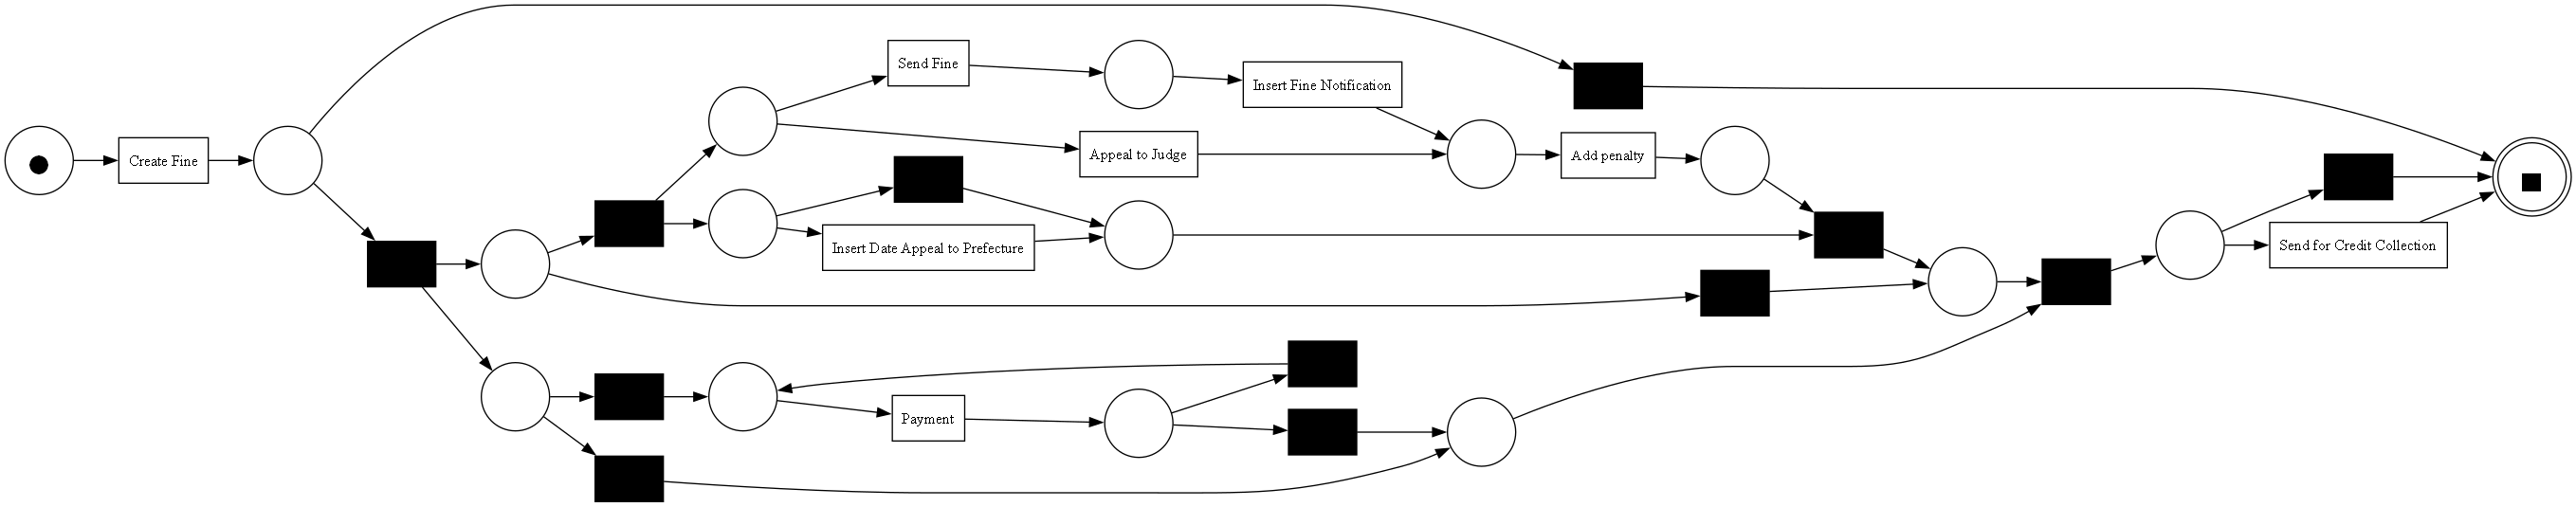

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[{'Add penalty',
  'Appeal to Judge',
  'Insert Date Appeal to Prefecture',
  'Insert Fine Notification',
  'Payment',
  'Send Fine'},
 {'Add penalty',
  'Appeal to Judge',
  'Insert Date Appeal to Prefecture',
  'Insert Fine Notification',
  'Send Fine'}]

In [15]:
engine.branching_sets

[{'Add penalty',
  'Appeal to Judge',
  'Insert Date Appeal to Prefecture',
  'Insert Fine Notification',
  'Payment',
  'Send Fine',
  'Send for Credit Collection'},
 {'Add penalty',
  'Appeal to Judge',
  'Insert Date Appeal to Prefecture',
  'Insert Fine Notification',
  'Send Fine'},
 {'Appeal to Judge', 'Insert Fine Notification', 'Send Fine'}]

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/road_fine-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

310

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,A19080,5,0,3,1,"(Create Fine, Send Fine, Insert Fine Notificat...","(Create Fine, Send Fine, Payment)",{2: {'Payment'}},79594,3240,10,window_variant_mixed
1,0,S106832,6,0,3,1,"(Create Fine, Send Fine, Insert Fine Notificat...","(Create Fine, Send Fine, Payment)",{2: {'Payment'}},79594,3240,10,window_variant_mixed
2,0,S160509,7,0,3,1,"(Create Fine, Send Fine, Insert Fine Notificat...","(Create Fine, Send Fine, Payment)",{2: {'Payment'}},79594,3240,10,window_variant_mixed
3,0,V11762,8,0,3,1,"(Create Fine, Send Fine, Insert Fine Notificat...","(Create Fine, Send Fine, Payment)",{2: {'Payment'}},79594,3240,10,window_variant_mixed
4,0,N78768,9,0,3,1,"(Create Fine, Send Fine, Insert Fine Notificat...","(Create Fine, Send Fine, Payment)",{2: {'Payment'}},79594,3240,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

4

In [25]:
len(exp_df_mul)

350

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,A19080,5,1,3,2,"(Send Fine, Insert Fine Notification, Add pena...","(Send Fine, Insert Date Appeal to Prefecture, ...","{2: {'Insert Date Appeal to Prefecture'}, 3: {...",72101,135,10,window_variant_mixed
1,0,N63824,6,1,3,2,"(Send Fine, Insert Fine Notification, Add pena...","(Send Fine, Insert Date Appeal to Prefecture, ...","{2: {'Insert Date Appeal to Prefecture'}, 3: {...",72101,135,10,window_variant_mixed
2,0,N83410,7,1,3,2,"(Send Fine, Insert Fine Notification, Add pena...","(Send Fine, Insert Date Appeal to Prefecture, ...","{2: {'Insert Date Appeal to Prefecture'}, 3: {...",72101,135,10,window_variant_mixed
3,0,A31097,8,1,3,2,"(Send Fine, Insert Fine Notification, Add pena...","(Send Fine, Insert Date Appeal to Prefecture, ...","{2: {'Insert Date Appeal to Prefecture'}, 3: {...",72101,135,10,window_variant_mixed
4,0,A12027,9,1,3,2,"(Send Fine, Insert Fine Notification, Add pena...","(Send Fine, Insert Date Appeal to Prefecture, ...","{2: {'Insert Date Appeal to Prefecture'}, 3: {...",72101,135,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/310 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,A19080,5,1,4,0.496543,0.278087,0.71500,0.537500,0.000000,...,0.502664,0.000000,0.252664,0.400,0.105329,0.250000,0.000000,0.000000,0.0,0.0
1,0,S106832,6,1,5,0.530766,0.391533,0.67000,0.606250,0.066667,...,0.684262,0.000000,0.309262,0.300,0.318524,0.375000,0.000000,0.000000,0.0,0.0
2,0,S160509,7,1,4,0.521042,0.482084,0.56000,0.602083,0.352941,...,0.924621,0.352941,0.233654,0.100,0.367308,0.333333,0.004692,0.004692,0.0,0.0
3,1,S71772,3,1,2,0.404653,0.234306,0.57500,0.452083,0.000000,...,0.134791,0.000000,0.051457,0.100,0.002915,0.083333,0.000000,0.000000,0.0,0.0
4,1,V6556,3,1,2,0.326950,0.223899,0.43000,0.362500,0.000000,...,0.158235,0.000000,0.074902,0.100,0.049804,0.083333,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,29,S54626,9,1,4,0.379162,0.278324,0.48000,0.463021,0.280952,...,0.188331,0.000000,0.063331,0.025,0.101662,0.125000,0.000000,0.000000,0.0,0.0
222,30,N53905,9,1,4,0.286780,0.202309,0.37125,0.367708,0.533333,...,0.641270,0.523810,0.034127,0.025,0.043254,0.083333,0.000000,0.896324,0.0,1.0
223,30,A373,9,1,4,0.473508,0.324515,0.62250,0.572396,0.000000,...,0.107855,0.000000,0.024521,0.025,0.024043,0.083333,0.000000,0.000000,0.0,0.0
224,30,N56915,9,1,4,0.373488,0.270726,0.47625,0.464062,0.409524,...,0.178416,0.000000,0.053416,0.025,0.081831,0.125000,0.000000,0.000000,0.0,0.0


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/350 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,A19080,5,2,4,0.550166,0.355331,0.745000,0.641667,0.187500,...,0.904708,0.187500,0.300541,0.400000,0.201083,0.416667,0.0,0.479646,0.0,0.500000
1,0,N63824,6,2,5,0.421798,0.333596,0.510000,0.497917,0.277778,...,0.612156,0.277778,0.126045,0.100000,0.152091,0.208333,0.0,0.488562,0.0,0.500000
2,0,N83410,7,2,6,0.499978,0.344955,0.655000,0.577083,0.350000,...,0.689637,0.350000,0.131303,0.100000,0.162607,0.208333,0.0,0.487457,0.0,0.500000
3,0,A31097,8,2,4,0.496532,0.413065,0.580000,0.581250,0.272727,...,0.691824,0.272727,0.169097,0.100000,0.238193,0.250000,0.0,0.489085,0.0,0.500000
4,1,N100658,4,2,2,0.276677,0.173355,0.380000,0.297917,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,33,N47801,10,3,5,0.391501,0.309668,0.473333,0.462500,0.482759,...,0.656379,0.482759,0.062510,0.033333,0.091686,0.111111,0.0,0.631843,0.0,0.666667
268,33,C16950,12,3,7,0.286115,0.187230,0.385000,0.334028,0.606061,...,0.679030,0.606061,0.031303,0.033333,0.029273,0.041667,0.0,0.625873,0.0,0.666667
269,34,S48577,9,3,3,0.344636,0.222605,0.466667,0.390972,0.481481,...,0.623409,0.444444,0.081743,0.100000,0.063486,0.097222,0.0,0.647411,0.0,0.666667
270,34,S76033,9,3,3,0.309062,0.181457,0.436667,0.376389,0.488889,...,0.587808,0.444444,0.046141,0.033333,0.058949,0.097222,0.0,0.322686,0.0,0.333333


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()